# Checking the performance of `pympc` positions for NEAs vs epoch of osculsionn

Here we assess the accuracy of NEA (Near-Earth Asteroid) positions predicted by `pympc` as a function of temporal distance from the osculation epoch of the catalogue. We use a series of MPC NEA catalogues with osculation epochs ranging from 0 to +30 days relative to a reference epoch. For each epoch, we compute the sky positions of all NEAs using both the catalogue corresponding to the exact epoch and a fixed, earlier catalogue. By comparing these positions, we quantify how prediction accuracy degrades as the time offset from the osculation epoch increases.

**Summary of Results**
> The vast majority (~99%) of NEA positions predicted by `pympc` remain within ~1 (4) arcseconds of their “true” osculation-epoch positions for predictions up to 15 (25) days past the catalogue (oscluation) epoch. For most NEAs, position predictions remain robust for a few weeks beyond the catalogue epoch, but accuracy rapidly can degrade for larger epoch offsets. Regularly (weekly) updating the local NEA catalogue is recommended for applications requiring ~arsecond positions.

## Setup

In [1]:
from pathlib import Path

from astropy.time import Time

from pympc import pympc

## Download the NEA catalogues for each epoch and save them with an appropriate name


Also determine the date we are downloading these catalogues relative to (i.e. the epoch of `m00`), so we can perform our later searches at appropriate epochs

In [6]:
cat_dir = "/tmp/pympc_nea_position_check"
nea_url = pympc.CATALOGUES["nea"]["url"]
delta_epochs = [-15, -10, -5, 0, 5, 10, 15]
reference_epochs = []
xephem_filepaths = []
try:
    for epoch in delta_epochs:
        numeric_prefix = "m" if epoch <= 0 else "p"
        neastub = f"nea{numeric_prefix}{abs(epoch):02d}"
        epoch_nea_url = nea_url.replace("neam00", neastub)
        pympc.CATALOGUES["nea"]["url"] = epoch_nea_url
        xephem_filepath = Path(pympc.update_catalogue(cat_dir=cat_dir, include_comets=False, source=None, show_progress=False))
        new_xephem_filepath = xephem_filepath.parent / f"mpcorb_nea_epoch_{neastub}.csv"
        xephem_filepath.rename(new_xephem_filepath)
        print(f"Downloaded catalogue from {pympc.CATALOGUES["nea"]["url"]} to {new_xephem_filepath}")
        with open(new_xephem_filepath) as f:
            line = f.readline()
        decimal_year = line.split(",")[9]
        reference_epoch = Time(decimal_year, format="decimalyear")
        reference_epochs.append(reference_epoch)
        print(f"Reference epoch: {reference_epoch.iso}")
        xephem_filepaths.append(new_xephem_filepath)
finally:
    pympc.CATALOGUES["nea"]["url"] = nea_url

Downloaded catalogue from https://minorplanetcenter.net/Extended_Files/neam15_extended.json.gz to /tmp/pympc_nea_position_check/xephem/mpcorb_nea_epoch_neam15.csv
Reference epoch: 2026-04-12 23:58:50.785
Downloaded catalogue from https://minorplanetcenter.net/Extended_Files/neam10_extended.json.gz to /tmp/pympc_nea_position_check/xephem/mpcorb_nea_epoch_neam10.csv
Reference epoch: 2026-04-17 23:58:50.781
Downloaded catalogue from https://minorplanetcenter.net/Extended_Files/neam05_extended.json.gz to /tmp/pympc_nea_position_check/xephem/mpcorb_nea_epoch_neam05.csv
Reference epoch: 2026-04-22 23:58:50.776
Downloaded catalogue from https://minorplanetcenter.net/Extended_Files/neam00_extended.json.gz to /tmp/pympc_nea_position_check/xephem/mpcorb_nea_epoch_neam00.csv
Reference epoch: 2026-04-27 23:58:50.772
Downloaded catalogue from https://minorplanetcenter.net/Extended_Files/neap05_extended.json.gz to /tmp/pympc_nea_position_check/xephem/mpcorb_nea_epoch_neap05.csv
Reference epoch: 2026

## Run `minor_planet_check` for each epoch and save the results

We use an all-sky cone-search to effectively get the positions of all NEAs in each search.

In [7]:
radius = 180 * 3600
ra = 0
dec = 0

In [8]:
search_epochs = [e.mjd for e in reference_epochs]
nea_epoch_tables = []
for epoch, xephem_filepath in zip(search_epochs, xephem_filepaths):
    print(f"Running `minor_planet_check` for epoch mjd={epoch}")
    tbl = pympc.minor_planet_check(ra, dec, epoch, radius, xephem_filepath=str(xephem_filepath))
    print(f"{len(tbl)} results")
    nea_epoch_tables.append(tbl)

Running `minor_planet_check` for epoch mjd=61142.9991989
Got 41576 results
Running `minor_planet_check` for epoch mjd=61147.99919885
Got 41576 results
Running `minor_planet_check` for epoch mjd=61152.9991988
Got 41576 results
Running `minor_planet_check` for epoch mjd=61157.99919875
Got 41576 results
Running `minor_planet_check` for epoch mjd=61162.9991987
Got 41576 results
Running `minor_planet_check` for epoch mjd=61167.99919865
Got 41576 results
Running `minor_planet_check` for epoch mjd=61172.9991986
Got 41576 results


## Calculate `pympc` positions for each epoch using only the earliest epoch (i.e. m15)

In [29]:
search_epochs = [e.mjd for e in reference_epochs]
xephem_filepath = xephem_filepaths[0]
nea_firstepoch_tables = []
for epoch in search_epochs:
    print(f"Running `minor_planet_check` for epoch mjd={epoch} using only the earliest epoch")
    tbl = pympc.minor_planet_check(ra, dec, epoch, radius, xephem_filepath=str(xephem_filepath), include_major_bodies=False)
    print(f"Got {len(tbl)} results")
    nea_firstepoch_tables.append(tbl)


Running `minor_planet_check` for epoch mjd=61142.9991989 using only the earliest epoch
Got 41549 results
Running `minor_planet_check` for epoch mjd=61147.99919885 using only the earliest epoch
Got 41549 results
Running `minor_planet_check` for epoch mjd=61152.9991988 using only the earliest epoch
Got 41549 results
Running `minor_planet_check` for epoch mjd=61157.99919875 using only the earliest epoch
Got 41549 results
Running `minor_planet_check` for epoch mjd=61162.9991987 using only the earliest epoch
Got 41549 results
Running `minor_planet_check` for epoch mjd=61167.99919865 using only the earliest epoch
Got 41549 results
Running `minor_planet_check` for epoch mjd=61172.9991986 using only the earliest epoch
Got 41549 results


## Compare the positions for their osclution epoch and those prederived from the earliest epoch

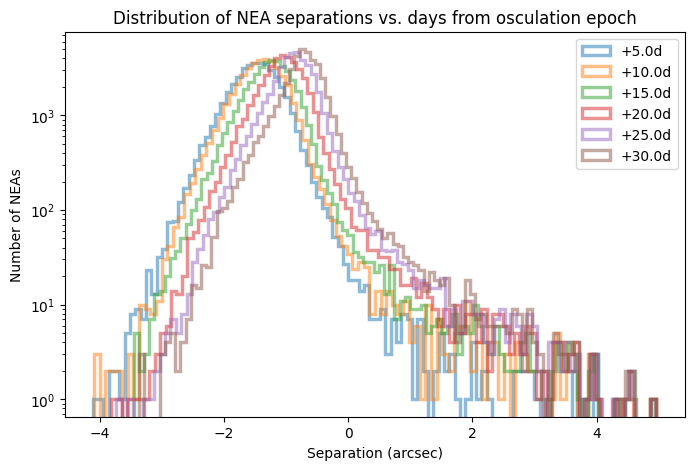

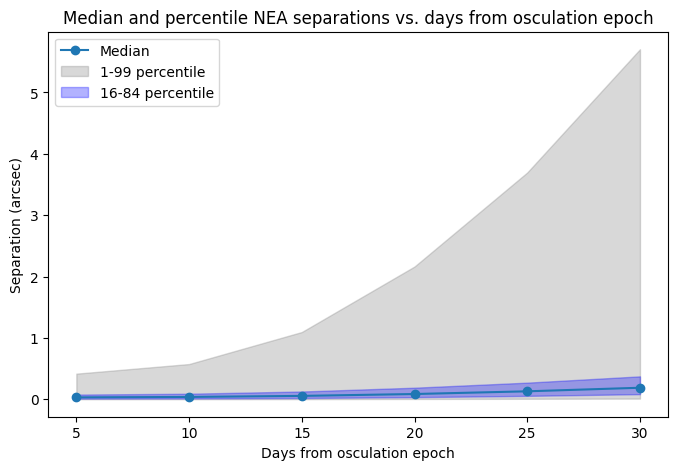

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

separations_by_epoch = []
days_from_epoch = []

for i, (tbl_true, tbl_pred) in enumerate(zip(nea_epoch_tables, nea_firstepoch_tables)):
    if i == 0:
        continue  # Don't compare the osculation epoch to itself
    # Match by designation (assuming 'desig' column exists and is unique)
    true_dict = {row['name']: row for row in tbl_true}
    pred_dict = {row['name']: row for row in tbl_pred}
    common_desigs = set(true_dict) & set(pred_dict)
    ras_true = [true_dict[d]['ra'] for d in common_desigs]
    decs_true = [true_dict[d]['dec'] for d in common_desigs]
    ras_pred = [pred_dict[d]['ra'] for d in common_desigs]
    decs_pred = [pred_dict[d]['dec'] for d in common_desigs]
    sc_true = SkyCoord(ras_true*u.deg, decs_true*u.deg)
    sc_pred = SkyCoord(ras_pred*u.deg, decs_pred*u.deg)
    sep = sc_true.separation(sc_pred).arcsec
    separations_by_epoch.append(sep)
    # Calculate days from osculation epoch (relative to m00)
    days_from_epoch.append(round((reference_epochs[i] - reference_epochs[0]).to(u.day).value, 0))

medians = [np.median(sep) for sep in separations_by_epoch]
p1 = [np.percentile(sep, 1) for sep in separations_by_epoch]
p16 = [np.percentile(sep, 16) for sep in separations_by_epoch]
p84 = [np.percentile(sep, 84) for sep in separations_by_epoch]
p99 = [np.percentile(sep, 99) for sep in separations_by_epoch]


# Plot
plt.figure(figsize=(8,5))
for i, sep in enumerate(separations_by_epoch):
    plt.hist(np.log10(sep), bins=100, alpha=0.5, histtype="step", lw=2.5, label=f"{days_from_epoch[i]:+}d")
plt.xlabel("Separation (arcsec)")
plt.ylabel("Number of NEAs")
plt.legend()
plt.title("Distribution of NEA separations vs. days from osculation epoch")
# plt.xscale("log")
plt.yscale("log")
plt.show()

# Optionally, plot median/percentile vs days
plt.figure(figsize=(8,5))
plt.plot(days_from_epoch, medians, marker='o', label='Median')
plt.fill_between(days_from_epoch, p1, p99, color='gray', alpha=0.3, label='1-99 percentile')
plt.fill_between(days_from_epoch, p16, p84, color='blue', alpha=0.3, label='16-84 percentile')
plt.xlabel("Days from osculation epoch")
plt.ylabel("Separation (arcsec)")
plt.title("Median and percentile NEA separations vs. days from osculation epoch")
plt.legend()
plt.show()